# **Wine Quality Prediction**

**BUSINESS UNDERSTANDING**

The main objective of this project is to predict red wine quality based on various chemical attributes such as volatile acidity, residual sugar, pH, alcohol content, and sulfur dioxide levels. These attributes influence the wine's body, flavor, aroma, and overall sensory experience, which ultimately determine its quality score.

This problem is framed as both a regression and classification task to compare how the result will be from framing the  problem as regression as opposed to classification. In the regression setting, the target variable is the wine quality score, ranging from 0 (very bad) to 10 (very excellent), while the predictor variables are the chemical properties of the wine. Each predictor represents measurable aspects of the wine's composition that can be controlled or adjusted during production. In the classification setting, wine quality can be grouped into categories (e.g., low, medium, high) to simplify decision-making.

This analysis can benefit multiple stakeholders. Winemakers can use the insights to optimize production processes by adjusting chemical compositions to improve quality. Distributors and quality inspectors can use the model to evaluate and select high-quality wines, which can inform sourcing decisions and pricing strategies. Additionally, consumers and wine enthusiasts can benefit from better identification of high-quality wines.

Understanding how these chemical attributes influence wine quality can lead to actionable improvements in production. For example, high volatile acidity gives a vinegar-like taste, which is associated with lower-quality wine. In contrast, optimizing alcohol content can enhance perceived quality by providing a fuller body. Sulphates act as preservatives that contribute to microbial stability and can also enhance flavor; therefore, an adequate amount is necessary for producing high-quality wine with a longer shelf life. However, total sulfur dioxide can negatively impact wine quality if present in excessive amounts, as it may produce an undesirable chemical taste. These adjustments can directly improve product consistency and increase market value.

The success of this project will be evaluated based on the model's ability to generalize to unseen data. For regression tasks, performance will be assessed using metrics such as R-squared (R²), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE), while classification performance will be evaluated using precision, recall, F1-score, and accuracy. In addition to predictive performance, success will also be measured by the model's ability to identify key features that significantly influence wine quality and to generate actionable insights aligned with business goals.

Finally, descriptive analytics will be performed to better understand the dataset, including summary statistics, distribution analysis, and correlation analysis between variables. This will help identify patterns, relationships, and potential feature importance before building predictive models.<br>
<br>

**DATA UNDERSTANDING**

1. Fixed acidity: Acids that don't evaporate easily, mainly tartaric acid<br>
Effect: Adds sourness/structure<br>
Insight: Higher = sharper taste<br>
2. Volatile acidity: Acids that evaporate, mainly acetic acid (vinegar)<br>
Effect: Too much → wine smells/tastes like vinegar<br>
Insight: High = bad quality signal<br>
3. Citric acid: Natural acid found in small amounts<br>
Effect: Adds freshness and flavor complexity<br>
Insight: Moderate levels are usually good<br>
4. Residual sugar: Sugar left after fermentation<br>
Effect: Determines sweetness<br>
Insight: Low → dry wine, High → sweet wine<br>
5. Chlorides: Salt content in the wine<br>
Effect: Too much → salty/off taste<br>
Insight: Higher levels can indicate lower quality<br>
6. Free sulfur dioxide (SO₂): Preservative that prevents oxidation and bacteria<br>
Effect: Protects wine freshness<br>
Insight: Needed, but too much can affect smell<br>
7. Total sulfur dioxide: Free SO₂ + bound SO₂<br>
Effect: Overall preservative level<br>
Insight: High levels can give chemical taste<br>
8. Density: How heavy the wine is compared to water<br>
Effect: Depends on sugar + alcohol<br>
Insight: Higher density → more sugar, Lower density → more alcohol<br>
9. pH: Acidity scale (0-14)<br>
Effect: Affects taste and stability<br>
Insight: Lower pH → more acidic (sharp), Higher pH → flatter taste<br>
10. Sulphates: Additives (like potassium sulphate)<br>
Effect: Enhance flavor and act as preservatives<br>
Insight: Often linked to better quality (in moderation)<br>
11. Alcohol: Ethanol content <br>
Effect: Body, warmth, and flavor<br>
Insight: Higher alcohol often correlates with higher quality<br>
<br>

**Target variable**: Quality<br>
- Score range: 0 (very bad) - 10 (very good)<br>
- Use for: Regression (predict score), Classification (e.g., good vs bad quality wine)<br>



# **1. Upload and clean data**

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

In [ ]:
# Read data
wine_quality = pd.read_csv("/content/drive/MyDrive/IS470_data/winequality-red.csv")
wine_quality

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
# Examine the number of rows and columns
wine_quality.shape

(1599, 12)

In [ ]:
# Examine missing value
wine_quality.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


No missing value was found.

In [ ]:
# Examine variable type
wine_quality.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


# **2. EDA**

In [ ]:
wine_quality.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


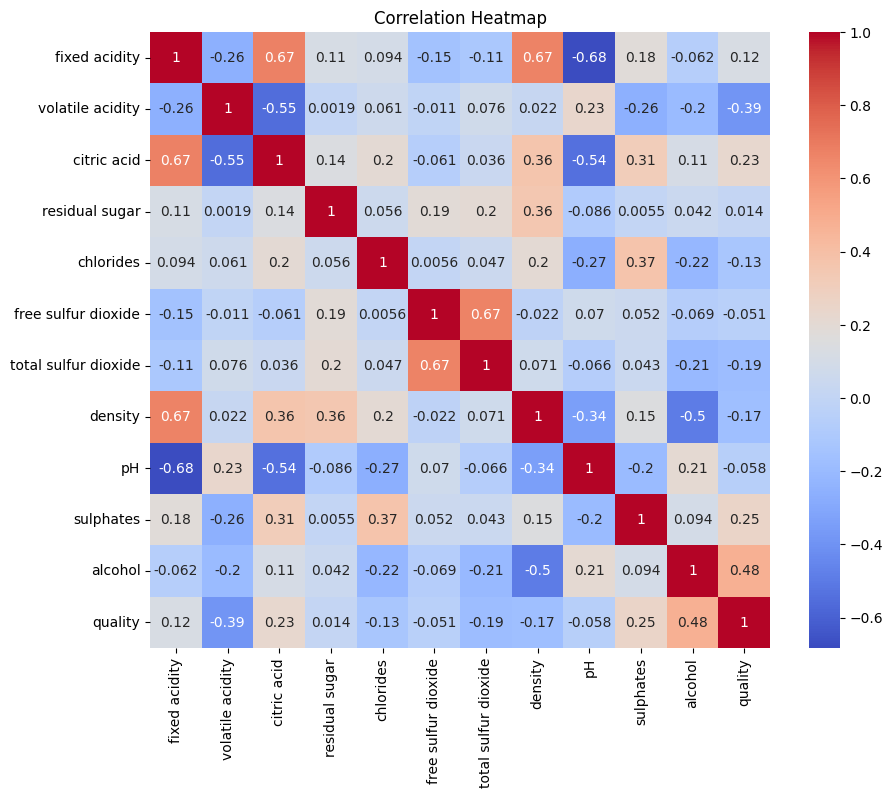

In [ ]:
# Correlation matrix - Exploring relationships among all numeric variables
plt.figure(figsize=(10,8))
sns.heatmap(wine_quality.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap was used to examine the relationships among the variables and wine quality. The results show that **alcohol** has the strongest positive correlation with quality, suggesting that wines with higher alcohol content tend to receive higher quality scores. **Sulphates** and **citric acid** also show positive relationships with quality, although weaker than alcohol. In contrast, **volatile acidity**, **total sulfur dioxide**, and **density** are negatively correlated with quality, indicating that higher values of these variables are generally associated with lower wine quality.

The heatmap also reveals moderate correlations among some predictor variables, such as between fixed acidity and citric acid, fixed acidity anddensity, fixed acidity and pH, and between free sulfur dioxide and total sulfur dioxide. These relationships suggest possible multicollinearity, which should be considered when interpreting the regression model coefficients.

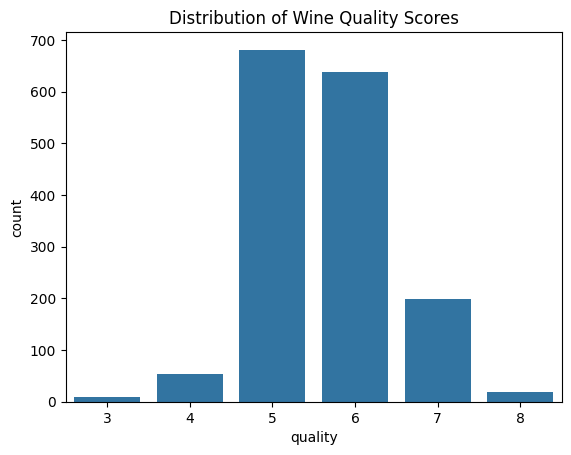

In [ ]:
# Countplot of wine quality
sns.countplot(x='quality', data=wine_quality)
plt.title('Distribution of Wine Quality Scores')
plt.show()

The distribution of wine quality scores shows that most wines are concentrated in the middle categories, 5 and 6. This indicates that the dataset is centered around average-quality wines, while very low-quality (3) and very high-quality (8) wines are rare. Quality 7 appears more often than 3, 4, and 8, but still much less frequently than 5 and 6.

Because quality scores 5 and 6 have the largest number of observations, results for these groups are more reliable. In contrast, the small counts for quality 3 and 8 mean that conclusions about those groups should be interpreted more carefully. Overall, the chart suggests that extreme wine quality scores are uncommon in this dataset.

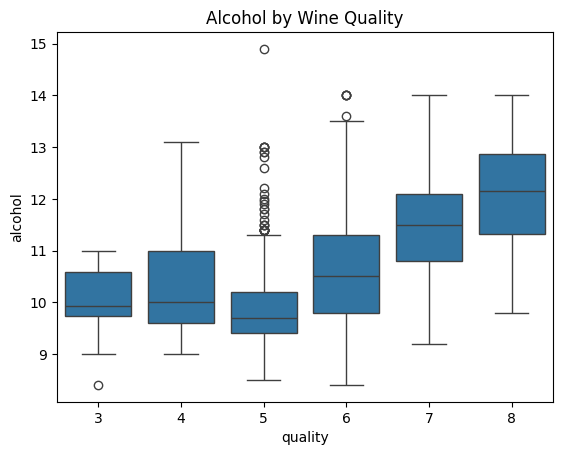

In [ ]:
# Boxplot of alcohol by wine quality
sns.boxplot(x='quality', y='alcohol', data=wine_quality)
plt.title('Alcohol by Wine Quality')
plt.show()

The median of alchohol level generally increases as quality increases. Wines with quality 7 and 8 tend to have higher alcohol levels than wines with quality 3 to 5.

Several alcohol outliers are present in quality 5 and 6 groups, indicating that some wines in these categories have unusually high alcohol content compared with others in the same quality level. This suggests that alcohol alone does not determine wine quality, and that other factors may also influence why wines are rated 5 or 6.

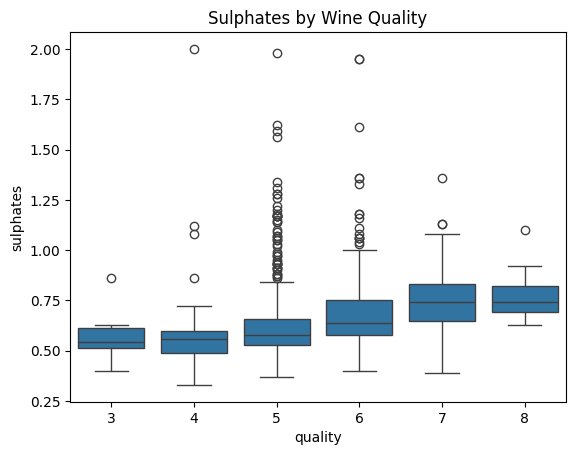

In [ ]:
# Boxplot of sulphates by wine quality
sns.boxplot(x='quality', y='sulphates', data=wine_quality)
plt.title('Sulphates by Wine Quality')
plt.show()

While sulphates generally show a positive association with wine quality, the presence of extreme outliers in mid-quality wines (5 and 6) suggests diminishing returns at higher concentrations. This indicates that optimal, rather than excessive, sulphate levels are important for achieving higher quality.

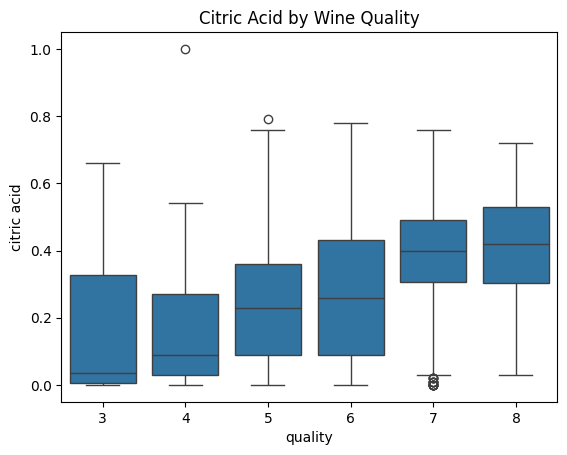

In [ ]:
# Boxplot of citric acid by wine quality
sns.boxplot(x='quality', y='citric acid', data=wine_quality)
plt.title('Citric Acid by Wine Quality')
plt.show()

Citric acid contributes to freshness and flavor complexity in wine. The boxplot shows that citric acid levels tend to increase with wine quality, with higher median values observed in wines rated 7 and 8 compared to lower-rated wines, indicating a positive relationship. However, a few low-value outliers are present in the quality 7 group, suggesting that some wines can still achieve high quality despite having low citric acid levels. This highlights that wine quality is influenced by multiple chemical factors rather than citric acid alone.

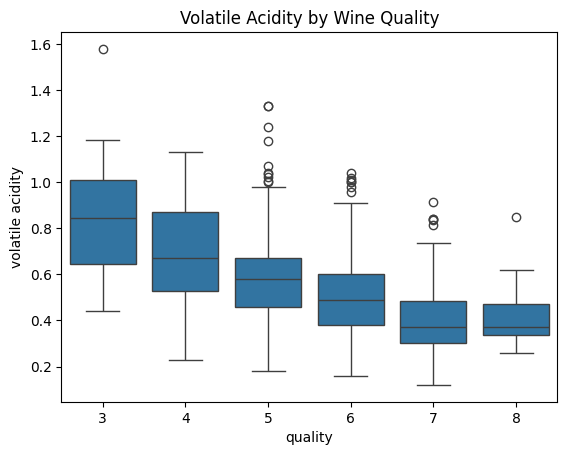

In [ ]:
# Boxplot of volatile acidity by wine quality
sns.boxplot(x='quality', y='volatile acidity', data=wine_quality)
plt.title('Volatile Acidity by Wine Quality')
plt.show()

High volatile acidity can give wine a vinegar-like smell and taste, which is often associated with lower-quality wine. The boxplot shows that the median volatile acidity generally decreases as wine quality increases, suggesting a negative relationship between volatile acidity and quality. There are also several outliers in the quality 5 and 6 groups, indicating that some wines in these categories have unusually high volatile acidity compared with others in the same quality level.

In [ ]:
# Average feature values by quality
quality_means = wine_quality.groupby('quality').mean(numeric_only=True)
print(quality_means)

         fixed acidity  volatile acidity  citric acid  residual sugar  \
quality                                                                 
3             8.360000          0.884500     0.171000        2.635000   
4             7.779245          0.693962     0.174151        2.694340   
5             8.167254          0.577041     0.243686        2.528855   
6             8.347179          0.497484     0.273824        2.477194   
7             8.872362          0.403920     0.375176        2.720603   
8             8.566667          0.423333     0.391111        2.577778   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
quality                                                                   
3         0.122500            11.000000             24.900000  0.997464   
4         0.090679            12.264151             36.245283  0.996542   
5         0.092736            16.983847             56.513950  0.997104   
6         0.084956            15.711599 

The table of average feature values by quality shows clear differences in the chemical profiles of wines across quality scores. In general, higher-quality wines tend to have higher average levels of alcohol, sulphates, and citric acid, while lower-quality wines tend to have higher average levels of volatile acidity, chlorides, total sulfur dioxide, and density. These patterns suggest that better-quality wines are associated with more favorable chemical characteristics.

Among the variables, alcohol shows one of the strongest upward trends, increasing from about 9.96 for quality 3 wines to about 12.09 for quality 8 wines. Volatile acidity shows the opposite pattern, decreasing substantially as quality increases. Sulphates and citric acid also rise steadily with quality, further suggesting a positive relationship with wine quality. Overall, the table supports the conclusion that wine quality is positively associated with alcohol, sulphates, and citric acid, and negatively associated with volatile acidity, free sulfur dioxide, and total sulfur dioxide.

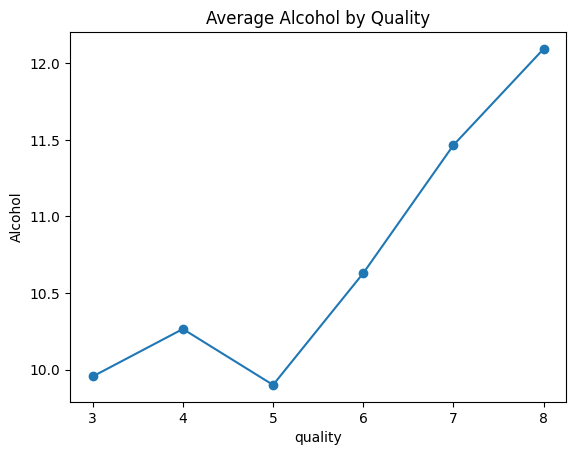

In [ ]:
# Trend plots of Average Alcohol by quality
wine_quality.groupby('quality')['alcohol'].mean().plot(marker='o')
plt.title('Average Alcohol by Quality')
plt.ylabel('Alcohol')
plt.show()

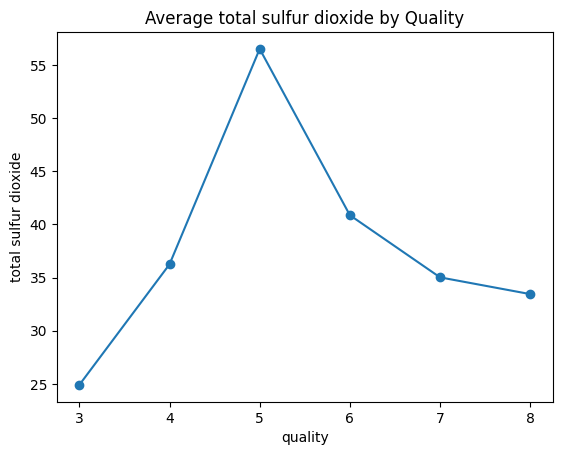

In [ ]:
# Trend plots of Total Sulfur Dioxide by quality
wine_quality.groupby('quality')['total sulfur dioxide'].mean().plot(marker='o')
plt.title('Average total sulfur dioxide by Quality')
plt.ylabel('total sulfur dioxide')
plt.show()

The trend plots show contrasting patterns between alcohol content and total sulfur dioxide across wine quality levels. Alcohol generally increases with quality, indicating that higher-quality wines tend to have higher alcohol content. In contrast, total sulfur dioxide peaks at quality level 5 and decreases as quality improves.

This inverse pattern is most evident at quality 5, where wines have the highest sulfur dioxide but relatively low alcohol. This suggests that excessive sulfur dioxide may negatively affect quality, while higher alcohol contributes positively. Overall, the results highlight the importance of balance, with higher-quality wines characterized by higher alcohol levels and moderate sulfur dioxide concentrations.

# **3. Partition the Dataset**

In [ ]:
# Examine the porportion of target variable for data set
target = wine_quality['quality']
print(target.value_counts(normalize=True))

quality
5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: proportion, dtype: float64


In [ ]:
# Partition the data
predictors = wine_quality.drop(['quality'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(1119, 11) (480, 11) (1119,) (480,)


Text(0.5, 1.0, 'Histogram of quality in the training data set')

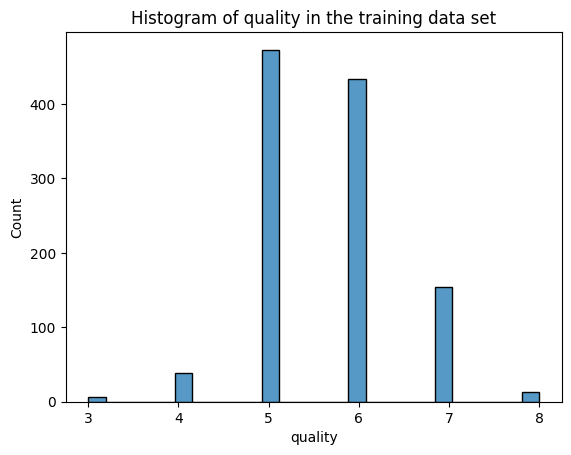

In [ ]:
# Examine the distribution of target variable for training data set
snsplot = sns.histplot(data = target_train)
snsplot.set_title("Histogram of quality in the training data set")

Text(0.5, 1.0, 'Histogram of quality in the testing data set')

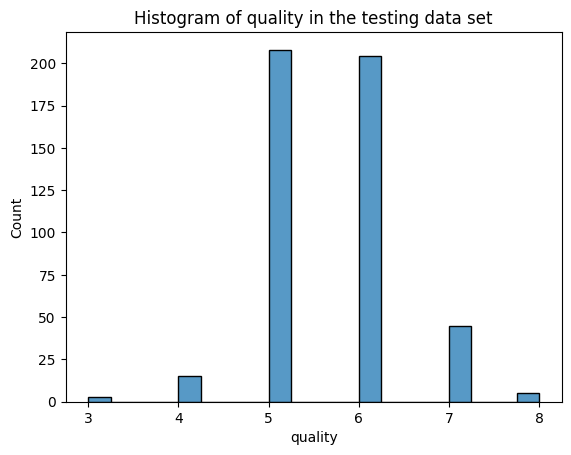

In [ ]:
# Examine the distribution of target variable for testing data set
snsplot = sns.histplot(data = target_test)
snsplot.set_title("Histogram of quality in the testing data set")


# **4. Build Model Prediction**

## I. Simple Linear Regression

In [ ]:
# Build a simple linear regression model with only alcohol as predictor
model1 = linear_model.LinearRegression()
model1.fit(predictors_train[['alcohol']], target_train)

LinearRegression()

In [ ]:
# Show model summary
X2 = sm.add_constant(predictors_train[['alcohol']])
y = target_train
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     303.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.29e-60
Time:                        01:56:40   Log-Likelihood:                -1235.3
No. Observations:                1119   AIC:                             2475.
Df Residuals:                    1117   BIC:                             2485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9289      0.215      8.985      0.0

The R-squared value is 0.214, indicating that alcohol explains approximately 21.4% of the variation in wine quality. The p-value for alcohol is 0, suggesting that it is a statistically significant predictor of quality. Additionally, for every one-unit increase in alcohol content, the predicted wine quality increases by approximately 0.3576.

In [ ]:
# Residual
res = est2.resid
print(res.describe())

count    1.119000e+03
mean     2.819312e-15
std      7.301221e-01
min     -2.862486e+00
25%     -3.988813e-01
50%     -1.830511e-01
75%      5.666309e-01
max      2.495112e+00
dtype: float64


The residuals have a mean close to zero, indicating that the model is not biased and does not consistently overestimate or underestimate wine quality. The standard deviation of approximately 0.73 suggests that the typical prediction error is less than one quality point. Most residuals fall within a relatively narrow range, although a few larger errors are present, as indicated by the minimum and maximum values.

Overall, the model provides reasonably accurate predictions but still exhibits some variability, suggesting that additional variables may be needed to improve performance.

In [ ]:
# Make predictions on testing data
prediction_on_test = model1.predict(predictors_test[['alcohol']])

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
MSE = mean_squared_error(target_test, prediction_on_test)
RMSE = MSE ** 0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.5230974814995663
RMSE: 0.6623121357628291


## II. Multiple Linear Regression

All available chemical attributes were retained as predictor variables in the OLS regression model. A review of the dataset showed no missing values and no obvious cheating variables. Although some predictors showed moderate correlations with one another, these relationships were not strong enough to justify excluding any variables, so the full set of chemical attributes was used in the analysis.

In [ ]:
# Build a multiple linear regression model with all predictors
model2 = linear_model.LinearRegression()
model2.fit(predictors_train, target_train)

LinearRegression()

In [ ]:
# Show model summary
import statsmodels.api as sm
X2 = sm.add_constant(predictors_train)
y = target_train
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     59.35
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.86e-103
Time:                        01:56:40   Log-Likelihood:                -1110.6
No. Observations:                1119   AIC:                             2245.
Df Residuals:                    1107   BIC:                             2305.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   21.0111 

The R-squared value of 0.371 indicates that the model explains 37.1% of the variability in wine quality, suggesting a moderate fit. Given that wine quality is partly subjective, this level of explanatory power is reasonable and indicates that the chemical variables have a meaningful, but not complete, influence on quality.

At the 5% significance level, volatile acidity, chlorides, total sulfur dioxide, sulphates, and alcohol are statistically significant predictors.

Focusing on the three most important variables:

- **Alcohol** has a positive effect on quality, where a one-unit increase in alcohol content increases the predicted quality by approximately 0.3576. This suggests that higher alcohol levels are associated with better wine quality.
- **Sulphates** also show a positive relationship, with a one-unit increase leading to an approximate 0.8542 increase in quality. This indicates that sulphates contribute to improved flavor and stability.
- **Volatile acidity** has a strong negative impact, where a one-unit increase decreases predicted quality by about 1.2139. This reflects the negative effect of vinegar-like acidity on wine quality.

Overall, these results highlight that higher alcohol and sulphate levels improve wine quality, while higher volatile acidity significantly reduces it.

In [ ]:
# Residual
res = est2.resid
print(res.describe())

count    1.119000e+03
mean    -1.583386e-13
std      6.530897e-01
min     -2.669533e+00
25%     -3.901852e-01
50%     -3.912982e-02
75%      4.463108e-01
max      1.795974e+00
dtype: float64


Residuals represent the difference between observed and predicted values. The residuals have a mean close to zero, indicating that the model is unbiased and does not consistently overestimate or underestimate wine quality. The standard deviation of about 0.65 suggests that typical prediction errors are relatively small. Most residuals fall between -0.39 and 0.45, showing that predictions are generally close to the actual values. However, the minimum and maximum values indicate a few larger errors. Overall, the model performs well with mostly small errors, though some variability remains.

In [ ]:
# Make predictions on testing data
prediction_on_test = model2.predict(predictors_test)

In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)

#RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
MSE = mean_squared_error(target_test, prediction_on_test)
RMSE = MSE ** 0.5    # or np.sqrt(MSE)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.48712621645927945
RMSE: 0.6330721652189464


## II. Regression Tree

In [ ]:
# Hypertuning Regression Tree Predictive Model
variable_sets = {
    'all_variables': list(predictors_train.columns),
    'top_5': ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide', 'chlorides', 'citric acid'],
    'top_4': ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide','citric acid'],
    'top_3': ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide', 'chlorides'],
    'top_2': ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide'],
    'top_1': ['alcohol', 'volatile acidity', 'sulphates']
}

for name, cols in variable_sets.items():
    print(f"\nVariable set: {name}")

    X_train = predictors_train[cols]
    X_test = predictors_test[cols]

    for depth in [3, 4, 5, 6, 8, 10, 12, 13, 14, 15]:
        model = DecisionTreeRegressor(random_state=0, max_depth=depth)
        model.fit(X_train, target_train)

        pred = model.predict(X_test)
        rmse = mean_squared_error(target_test, pred) ** 0.5
        mae = mean_absolute_error(target_test, pred)

        print(f"max_depth={depth}, MAE={mae:.4f}, RMSE={rmse:.4f}")


Variable set: all_variables
max_depth=3, MAE=0.5454, RMSE=0.6981
max_depth=4, MAE=0.5325, RMSE=0.6943
max_depth=5, MAE=0.5257, RMSE=0.6942
max_depth=6, MAE=0.5181, RMSE=0.6937
max_depth=8, MAE=0.5228, RMSE=0.7379
max_depth=10, MAE=0.4712, RMSE=0.7413
max_depth=12, MAE=0.4755, RMSE=0.7740
max_depth=13, MAE=0.4662, RMSE=0.7730
max_depth=14, MAE=0.4576, RMSE=0.7823
max_depth=15, MAE=0.4689, RMSE=0.7908

Variable set: top_5
max_depth=3, MAE=0.5454, RMSE=0.6981
max_depth=4, MAE=0.5201, RMSE=0.6850
max_depth=5, MAE=0.5222, RMSE=0.6820
max_depth=6, MAE=0.5426, RMSE=0.7277
max_depth=8, MAE=0.5440, RMSE=0.7976
max_depth=10, MAE=0.5318, RMSE=0.8268
max_depth=12, MAE=0.5363, RMSE=0.8608
max_depth=13, MAE=0.5164, RMSE=0.8628
max_depth=14, MAE=0.5009, RMSE=0.8468
max_depth=15, MAE=0.5160, RMSE=0.8582

Variable set: top_4
max_depth=3, MAE=0.5390, RMSE=0.6975
max_depth=4, MAE=0.5124, RMSE=0.6783
max_depth=5, MAE=0.5214, RMSE=0.6822
max_depth=6, MAE=0.5144, RMSE=0.7015
max_depth=8, MAE=0.5105, RMSE=0

The lowest MAE (0.4576) was achieved using all variables with a maximum depth of 14, although this configuration resulted in a higher RMSE of (0.7823). In contrast, the lowest RMSE (0.6647) was obtained using the top 1 variable, which are 'alcohol', 'volatile acidity', 'sulphates', with a maximum depth of 4, with a corresponding MAE of (0.5241).

The model with the lowest RMSE was selected as the best overall model because it penalizes larger errors more heavily, making it more suitable for minimizing significant prediction mistakes, while MAE was also considered to evaluate average prediction error.

[Text(0.5, 0.9, 'fixed acidity <= 10.525\nsquared_error = 0.677\nsamples = 1119\nvalue = 5.651'),
 Text(0.25, 0.7, 'citric acid <= 0.555\nsquared_error = 0.434\nsamples = 690\nvalue = 5.384'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'fixed acidity <= 10.15\nsquared_error = 0.281\nsamples = 230\nvalue = 5.122'),
 Text(0.0625, 0.3, 'citric acid <= 0.535\nsquared_error = 0.261\nsamples = 205\nvalue = 5.083'),
 Text(0.03125, 0.1, 'squared_error = 0.229\nsamples = 144\nvalue = 5.021'),
 Text(0.09375, 0.1, 'squared_error = 0.308\nsamples = 61\nvalue = 5.23'),
 Text(0.1875, 0.3, 'volatile acidity <= 0.635\nsquared_error = 0.326\nsamples = 25\nvalue = 5.44'),
 Text(0.15625, 0.1, 'squared_error = 0.24\nsamples = 20\nvalue = 5.6'),
 Text(0.21875, 0.1, 'squared_error = 0.16\nsamples = 5\nvalue = 4.8'),
 Text(0.375, 0.5, 'volatile acidity <= 0.335\nsquared_error = 0.458\nsamples = 460\nvalue = 5.515'),
 Text(0.3125, 0.3, 'citric acid <= 0.715\nsquared_error = 0.508\nsamples = 51\nvalue = 6.

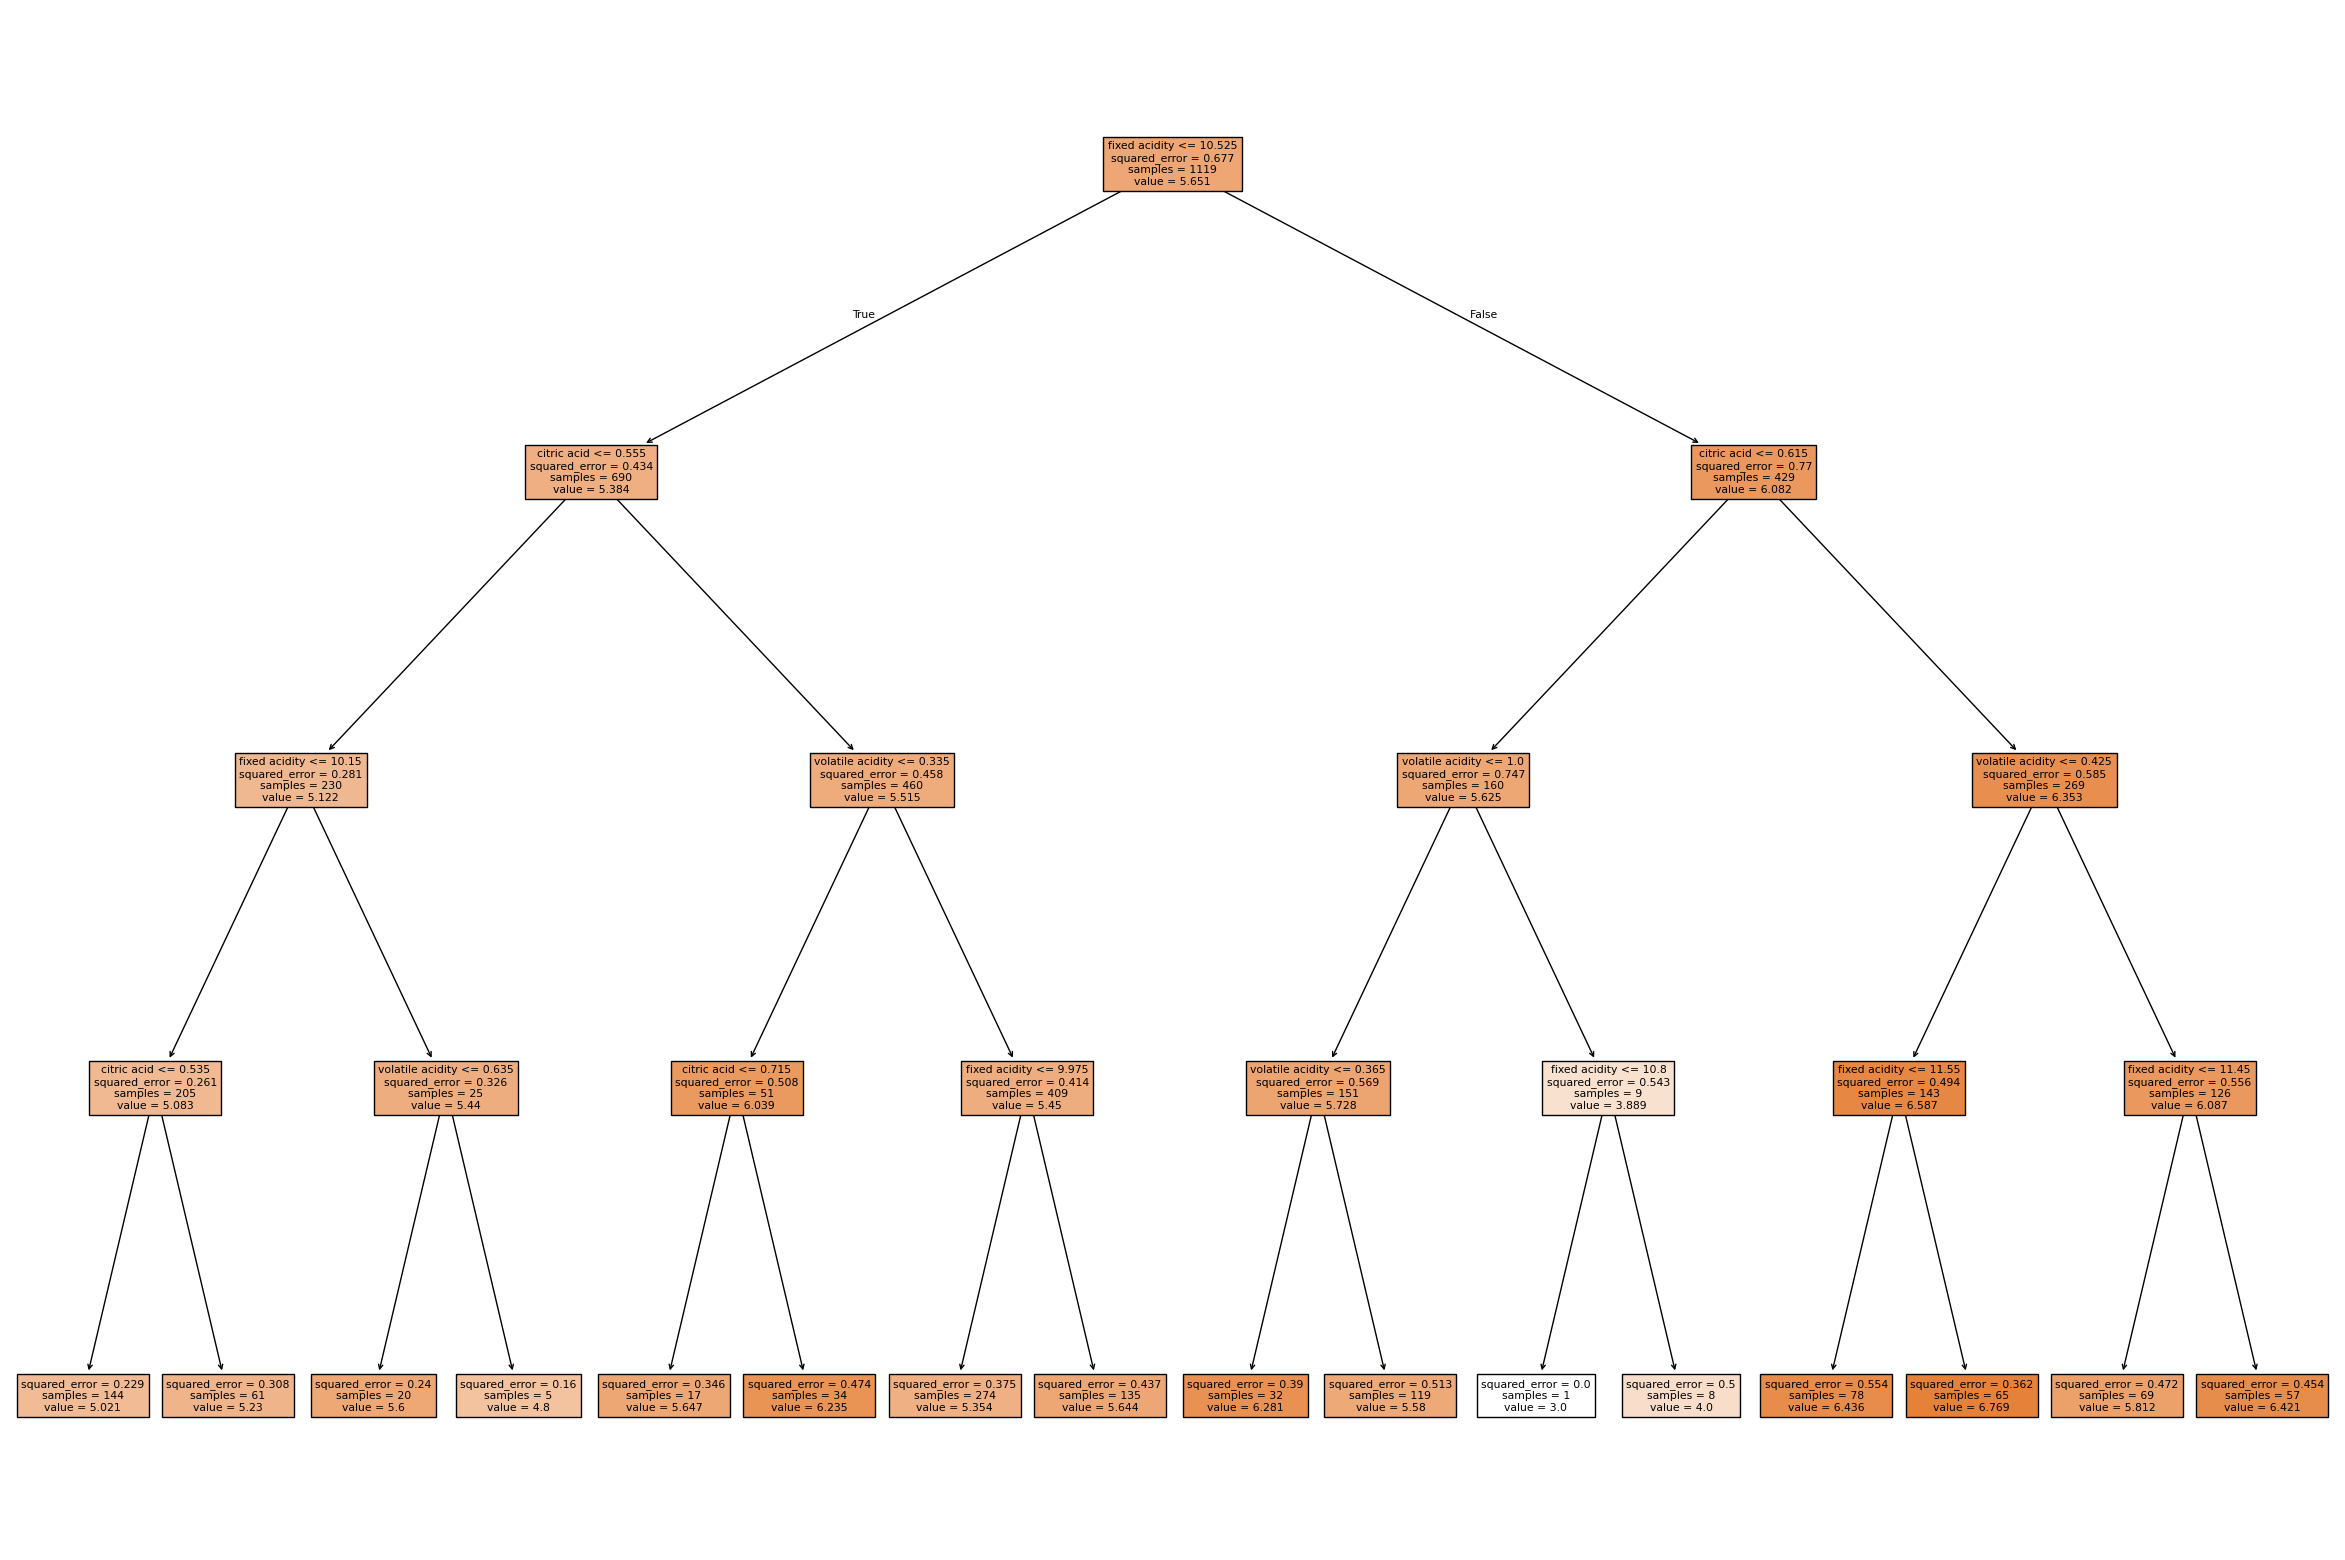

In [ ]:
# Build a regression tree model with max_depth=4
selected_var = ['alcohol', 'volatile acidity', 'sulphates']
model3 = DecisionTreeRegressor(random_state=0, max_depth=4)
model3.fit(predictors_train[selected_var], target_train)

fig = plt.figure(figsize=(30,20))
tree.plot_tree(model3,
               feature_names=list(predictors_train.columns),
               filled=True)

## III. Support Vector Regression (SVR)

In [ ]:
# Scaled the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
predictors_train_scaled = scaler.fit_transform(predictors_train)
predictors_test_scaled = scaler.transform(predictors_test)

Feature scaling was applied before training the SVR model to ensure optimal performance and model stability.

In [ ]:
# For loop to find the best C
best_c = None
best_rmse = float('inf')
best_mae = None

for c_value in [0.01, 0.1, 1, 10, 100]:
    model_svr = SVR(C=c_value)
    model_svr.fit(predictors_train_scaled, target_train)

    prediction_on_test = model_svr.predict(predictors_test_scaled)

    mae = mean_absolute_error(target_test, prediction_on_test)
    rmse = mean_squared_error(target_test, prediction_on_test) ** 0.5

    print(f"C = {c_value}, MAE = {mae:.4f}, RMSE = {rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_mae = mae
        best_c = c_value

print("\nBest C:", best_c)
print("Best MAE:", round(best_mae, 4))
print("Best RMSE:", round(best_rmse, 4))

C = 0.01, MAE = 0.5177, RMSE = 0.6665
C = 0.1, MAE = 0.4757, RMSE = 0.6340
C = 1, MAE = 0.4606, RMSE = 0.6224
C = 10, MAE = 0.4764, RMSE = 0.6678
C = 100, MAE = 0.5669, RMSE = 0.8015

Best C: 1
Best MAE: 0.4606
Best RMSE: 0.6224


The performance of the SVR model improves as C increases from 0.01 to 1, with both MAE and RMSE decreasing. The best results are achieved at C=1, where the model attains the lowest MAE (0.4606) and RMSE (0.6224), indicating a good balance between bias and variance. However, performance declines at higher values of C (10 and 100), suggesting overfitting. Overall, C=1 is selected as the best model due to its superior predictive accuracy and generalization.

## IV. Multi-layer Perceptron (MLP)

Feature scaling was applied before training the MLP model to ensure optimal performance and model stability.

In [ ]:
# For loop to find the best hidden layer sizes

hidden_layer_options = [
    (20,),
    (40,),
    (16,8),
    (10,10),
    (18,12),
    (25,8),
    (8,5,4),
    (15,10,5) ]

best_hidden_layers = None
best_rmse = float('inf')
best_mae = None

for hidden_layers in hidden_layer_options:
    model_mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        random_state=0,
        max_iter=2000
    )

    model_mlp.fit(predictors_train_scaled, target_train)
    prediction_on_test = model_mlp.predict(predictors_test_scaled)

    mae = mean_absolute_error(target_test, prediction_on_test)
    rmse = mean_squared_error(target_test, prediction_on_test) ** 0.5

    print(f"hidden_layer_sizes = {hidden_layers}, MAE = {mae:.6f}, RMSE = {rmse:.6f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_mae = mae
        best_hidden_layers = hidden_layers

print("\nBest hidden_layer_sizes:", best_hidden_layers)
print("Best MAE:", round(best_mae, 6))
print("Best RMSE:", round(best_rmse, 6))

hidden_layer_sizes = (20,), MAE = 0.511225, RMSE = 0.665238
hidden_layer_sizes = (40,), MAE = 0.504341, RMSE = 0.671041
hidden_layer_sizes = (16, 8), MAE = 0.496621, RMSE = 0.637176
hidden_layer_sizes = (10, 10), MAE = 0.500475, RMSE = 0.653659
hidden_layer_sizes = (18, 12), MAE = 0.502352, RMSE = 0.656614
hidden_layer_sizes = (25, 8), MAE = 0.495880, RMSE = 0.659088
hidden_layer_sizes = (8, 5, 4), MAE = 0.515113, RMSE = 0.665886
hidden_layer_sizes = (15, 10, 5), MAE = 0.502926, RMSE = 0.663618

Best hidden_layer_sizes: (16, 8)
Best MAE: 0.496621
Best RMSE: 0.637176


Models with two hidden layers tend to perform better than those with a single layer or deeper, more complex structures. The best performance is achieved with the architecture (16, 8), which yields the lowest MAE (0.4966) and RMSE (0.6372), indicating strong predictive accuracy.

Simpler models, such as (20,) and (40,), show slightly higher errors, suggesting limited capacity to capture complex relationships. On the other hand, deeper networks like (8, 5, 4) and (15, 10, 5) do not improve performance and may introduce unnecessary complexity, leading to slight overfitting or instability.

Overall, the (16, 8) model is selected as the best architecture, as it provides the lowest prediction error and achieves a good balance between model complexity and generalization.

# **5. Regression Models Comparison**

In [ ]:
# Table comparing MAE and RMSE
model_comparison = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Regression Tree', 'SVR', 'MLP'],
    'MAE': [
        0.5230974814995663,
        0.486760962500078,
        0.5241,
        0.4606,
        0.496621
        ],
    'RMSE': [
        0.6623121357628291,
        0.6332438932708349,
        0.6647,
        0.6224,
        0.637176
    ]
}

df_comparison = pd.DataFrame(model_comparison)
print("Model Comparison (MAE and RMSE):")
display(df_comparison.sort_values(by='RMSE'))

Model Comparison (MAE and RMSE):


,Model,MAE,RMSE
3,SVR,0.460600,0.622400
1,Multiple Linear Regression,0.486761,0.633244
4,MLP,0.496621,0.637176
0,Simple Linear Regression,0.523097,0.662312
2,Regression Tree,0.524100,0.664700


The SVR model performed the best overall, achieving the lowest MAE (0.4623) and RMSE (0.6242), indicating the highest predictive accuracy among all models.

The multiple linear regression model was the second-best performer, with lower errors than the simple linear regression, regression tree, and MLP models. This shows that using all predictors improves performance compared to simple linear regression, where the model relying on a single variable only.

The regression tree achieved its best RMSE using only three variables: alcohol, volatile acidity, and sulphates. This highlight that a small set of key features can still provide reasonable predictions. However, it also produced the highest overall RMSE, indicating larger prediction errors despite its interpretability.

The MLP model performed similarly to multiple linear regression but did not outperform SVR. Although it can capture non-linear relationships, its added complexity did not lead to better predictive performance in this case.

Overall, the models demonstrate reasonable accuracy, with the best model (SVR) achieving an MAE of 0.46, meaning predictions differ from actual wine quality by less than half a point on average. RMSE values between 0.62 and 0.66 further indicate that most prediction errors are within approximately one quality point, although some larger errors are present.

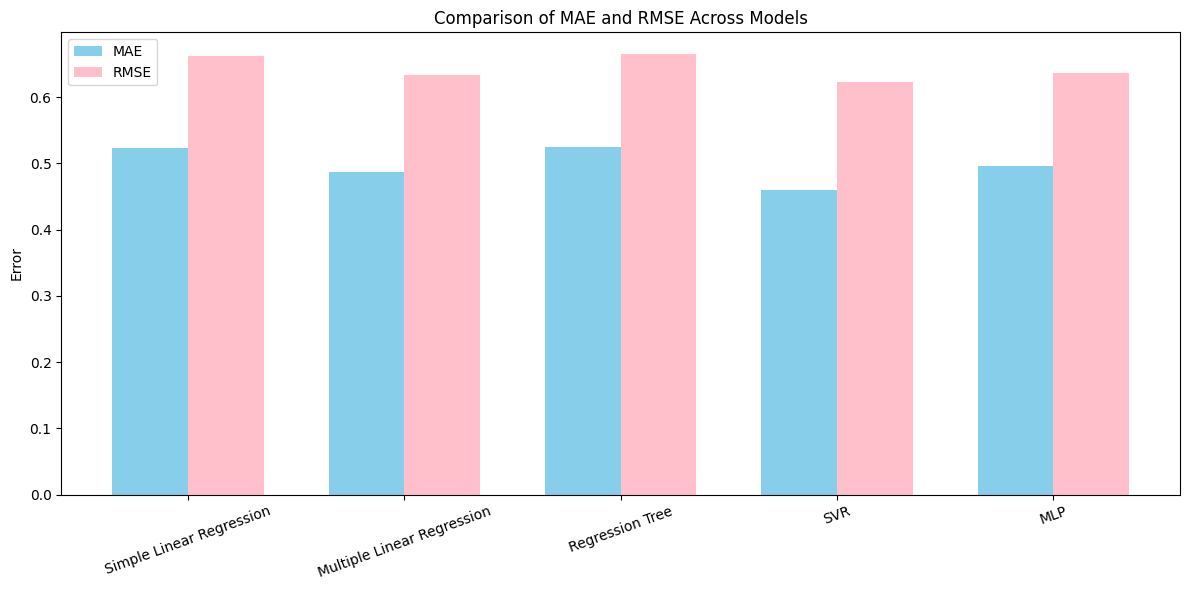

In [ ]:
# Bar chart that encompasses the MAE and RMSE for all models
x = np.arange(len(df_comparison['Model']))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, df_comparison['MAE'], width, label='MAE', color='skyblue')
plt.bar(x + width/2, df_comparison['RMSE'], width, label='RMSE', color='pink')

plt.xticks(x, df_comparison['Model'], rotation=20)
plt.ylabel('Error')
plt.title('Comparison of MAE and RMSE Across Models')
plt.legend()
plt.tight_layout()
plt.show()

# **6. Classification**

In [ ]:
# Assign wine quality
wine_quality['quality_class'] = (wine_quality['quality'] >= 6).astype(int)

A new variable, quality_class, was created by grouping wines into two categories:
- 1-5 = lower-quality wine (0)
- 6-10 = higher-quality wine (1)


In [ ]:
# Check proportion of the wine quality
wine_quality['quality_class'].value_counts()
wine_quality['quality_class'].value_counts(normalize=True)

,proportion
quality_class,
1,0.534709
0,0.465291


In [ ]:
# Partition data
target = wine_quality['quality_class']
predictors = wine_quality.drop(['quality', 'quality_class'], axis=1)

predictors_train, predictors_test, target_train, target_test = train_test_split(
    predictors, target, test_size=0.3, random_state=0, stratify=target)

print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(1119, 11) (480, 11) (1119,) (480,)


In [ ]:
# Taking steps to balance the training data
# Combine predictors_train and target_train into one DataFrame
combined_train_df = pd.concat([predictors_train, target_train], axis=1)

# Separate majority and minority classes
minority_df = combined_train_df[combined_train_df['quality_class'] == 0]
majority_df = combined_train_df[combined_train_df['quality_class'] == 1]

# Undersample the majority class randomly to match the minority class size
undersampled_majority = majority_df.sample(n=len(minority_df), random_state=5)

# Combine the undersampled majority class and the minority class
undersampled_data = pd.concat([undersampled_majority, minority_df])

# Shuffle the combined DataFrame
balanced_data = undersampled_data.sample(frac=1, random_state=5)

# Split back into predictors_train and target_train
predictors_train = balanced_data.drop(columns=['quality_class'])
target_train = balanced_data['quality_class']

In [ ]:
# Examine the porportion of target variable for train set
print(target_train.value_counts(normalize=True), target_train.shape)

quality_class
1    0.5
0    0.5
Name: proportion, dtype: float64 (1042,)


In [ ]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

quality_class
1    0.535417
0    0.464583
Name: proportion, dtype: float64


## I. Random Forest

In [ ]:
best_rf_n_estimators = 0
best_rf_max_depth = 0
best_rf_f1_positive = 0

n_estimators_values = [10, 30, 50, 100]
max_depth_values = [5, 10, 15, 20]

for n_est in n_estimators_values:
    for m_depth in max_depth_values:
        model_RF = RandomForestClassifier(n_estimators=n_est, max_depth=m_depth, random_state=1)
        model_RF.fit(predictors_train, target_train)

        prediction_on_test_RF = model_RF.predict(predictors_test)
        report_RF = classification_report(target_test, prediction_on_test_RF, output_dict=True)

        f1_positive_RF = report_RF['1']['f1-score']

        print(f"\n----- n_estimators = {n_est}, max_depth = {m_depth} -----")
        print(classification_report(target_test, prediction_on_test_RF))
        print(f"F1-score for class 1: {f1_positive_RF:.4f}")

        if f1_positive_RF > best_rf_f1_positive:
            best_rf_f1_positive = f1_positive_RF
            best_rf_n_estimators = n_est
            best_rf_max_depth = m_depth

print(f"\nBest Random Forest Hyperparameters: n_estimators={best_rf_n_estimators}, max_depth={best_rf_max_depth}")
print(f"Best F1-score for class 1: {best_rf_f1_positive:.4f}")


----- n_estimators = 10, max_depth = 5 -----
              precision    recall  f1-score   support

           0       0.74      0.77      0.76       223
           1       0.79      0.77      0.78       257

    accuracy                           0.77       480
   macro avg       0.77      0.77      0.77       480
weighted avg       0.77      0.77      0.77       480

F1-score for class 1: 0.7802

----- n_estimators = 10, max_depth = 10 -----
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       223
           1       0.83      0.77      0.80       257

    accuracy                           0.79       480
   macro avg       0.79      0.80      0.79       480
weighted avg       0.80      0.79      0.79       480

F1-score for class 1: 0.8000

----- n_estimators = 10, max_depth = 15 -----
              precision    recall  f1-score   support

           0       0.72      0.82      0.77       223
           1       0.82      0.73      

The Random Forest model with n_estimators=100 and max_depth=15 achieved the best overall performance, with an accuracy of 0.81. For class 1 (higher-quality wine), the model obtained a precision of 0.84, recall of 0.81, and an F1-score of 0.82, indicating strong and balanced performance in identifying high-quality wines.

The selection of this model was based primarily on its recall and F1-score for class 1. Since the objective is to identify higher-quality wines, recall is especially important, as it measures the model's ability to correctly detect these wines. A higher recall ensures that fewer high-quality wines are missed. The F1-score further supports this choice by balancing precision and recall, confirming that the model performs well without excessively misclassifying lower-quality wines as high-quality.

Overall, this model provides a good balance between accuracy and the ability to correctly identify high-quality wines, making it the most suitable choice for this task.

## II. Support Vector Classification (SVC)

In [ ]:
# Scale the data

scaler = StandardScaler()
predictors_train_scaled = scaler.fit_transform(predictors_train)
predictors_test_scaled = scaler.transform(predictors_test)

Feature scaling was applied before training the SVC model to ensure optimal performance and model stability.

In [ ]:
from sklearn.svm import SVC

best_c = 0
best_svc_f1_positive = 0

# Loop through different C values
for c_value in [0.01, 0.1, 1, 10, 100]:
    modelSVC = SVC(C=c_value, random_state=0)
    modelSVC.fit(predictors_train_scaled, target_train)

    prediction_on_test_svc = modelSVC.predict(predictors_test_scaled)
    report_svc = classification_report(target_test, prediction_on_test_svc, output_dict=True)

    # Get the F1-score for class 1 (higher-quality wine)
    f1_positive_svc = report_svc['1']['f1-score']

    print(f"\n----- C = {c_value} -----")
    print(classification_report(target_test, prediction_on_test_svc))
    print(f"Exact F1-score for class 1: {f1_positive_svc:.6f}")

    if f1_positive_svc > best_svc_f1_positive:
        best_svc_f1_positive = f1_positive_svc
        best_c = c_value

print(f"\nBest C for SVC: {best_c}")
print(f"Best F1-score for class 1 (higher-quality wine): {best_svc_f1_positive:.4f}")


----- C = 0.01 -----
              precision    recall  f1-score   support

           0       0.64      0.87      0.74       223
           1       0.83      0.58      0.68       257

    accuracy                           0.71       480
   macro avg       0.74      0.72      0.71       480
weighted avg       0.74      0.71      0.71       480

Exact F1-score for class 1: 0.683486

----- C = 0.1 -----
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       223
           1       0.81      0.68      0.74       257

    accuracy                           0.74       480
   macro avg       0.75      0.75      0.74       480
weighted avg       0.75      0.74      0.74       480

Exact F1-score for class 1: 0.741053

----- C = 1 -----
              precision    recall  f1-score   support

           0       0.73      0.82      0.77       223
           1       0.82      0.74      0.78       257

    accuracy                           0.77   

The SVC model with C=1 achieved an overall accuracy of 0.77. For class 1 (higher-quality wine), the model obtained a precision of 0.82, recall of 0.74, and an F1-score of approximately 0.78, indicating reasonably strong performance in identifying high-quality wines.

While the precision is relatively high, indicating that predicted high-quality wines are often correct, the slightly lower recall suggests that some high-quality wines are still missed. The F1-score reflects a balanced trade-off between precision and recall.

Overall, the SVC model performs well, but compared to the Random Forest model, it shows slightly lower recall for class 1, making it less effective in capturing all high-quality wines. Nonetheless, it remains a solid model with good predictive capability.

## III. Logistic Regression

Feature scaling was applied before training Logistic Regression model to ensure optimal performance and model stability.

In [ ]:
# For loop to find the best C

best_c = 0
best_log_f1_positive = 0

# Loop through different C values
for c_value in [0.01, 0.1, 1, 10, 100]:
    modelLOG = LogisticRegression(C=c_value, class_weight='balanced', max_iter=1000, random_state=0)
    modelLOG.fit(predictors_train_scaled, target_train)

    prediction_on_test_log = modelLOG.predict(predictors_test_scaled)
    report_log = classification_report(target_test, prediction_on_test_log, output_dict=True)

    # Get the F1-score for class 1 (higher-quality wine)
    f1_positive_log = report_log['1']['f1-score']

    print(f"\n----- C = {c_value} -----")
    print(classification_report(target_test, prediction_on_test_log))

    if f1_positive_log > best_log_f1_positive:
        best_log_f1_positive = f1_positive_log
        best_c = c_value

print(f"\nBest C for Logistic Regression: {best_c}")
print(f"Best F1-score for class 1 (higher-quality wine): {best_log_f1_positive:.4f}")


----- C = 0.01 -----
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       223
           1       0.80      0.73      0.76       257

    accuracy                           0.76       480
   macro avg       0.76      0.76      0.76       480
weighted avg       0.76      0.76      0.76       480


----- C = 0.1 -----
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       223
           1       0.80      0.75      0.77       257

    accuracy                           0.76       480
   macro avg       0.76      0.76      0.76       480
weighted avg       0.76      0.76      0.76       480


----- C = 1 -----
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       223
           1       0.79      0.75      0.77       257

    accuracy                           0.76       480
   macro avg       0.76      0.76      0.76       480
weighted avg

The Logistic Regression model with C=0.1 achieved an overall accuracy of 0.76. For class 1 (higher-quality wine), the model obtained a precision of 0.80, recall of 0.75, and an F1-score of 0.77, indicating a fairly balanced performance in identifying high-quality wines.

# **7. Classification Model Comparision**

In [ ]:
# Table comparing classification performance for class 1

model_comparison_class = {
    'Model': ['Random Forest', 'SVC', 'Logistic Regression'],
    'Precision': [0.84, 0.82, 0.80],
    'Recall': [0.81, 0.74, 0.75],
    'F1-Score': [0.8214, 0.7762, 0.7711]
}

df_comparison_class = pd.DataFrame(model_comparison_class)
print("Model Comparison for Class 1 (Higher-Quality Wine):")
display(df_comparison_class.sort_values(by='F1-Score', ascending=False))

Model Comparison for Class 1 (Higher-Quality Wine):


,Model,Precision,Recall,F1-Score
0,Random Forest,0.84,0.81,0.8214
1,SVC,0.82,0.74,0.7762
2,Logistic Regression,0.80,0.75,0.7711


Based on the performance for class 1 (high-quality wine), the Random Forest model achieved the best results, with the highest precision, recall, and F1-score. This indicates that it is the most effective model for identifying high-quality wines.

The SVC and Logistic Regression models show similar performance, with comparable precision and recall values. However, both models perform slightly worse than Random Forest, particularly in recall, meaning they are less effective at capturing all high-quality wines.

# **8. Final Evaluation**

The primary objective of this project was to predict wine quality scores using chemical attributes through regression models. However, model performance was inherently limited by the subjective nature of wine quality, where similar wines may receive different ratings due to human evaluation. This introduces label noise, reducing the achievable predictive accuracy.

Among the regression models tested, Support Vector Regression (SVR) achieved the best performance, with the lowest error metrics (MAE: 0.460600, RMSE: 0.622400). However, relatively low R² values across models indicate that chemical features alone do not fully explain variations in perceived quality.

To address this, a classification approach was introduced by grouping wines into low- vs high-quality categories, simplifying the prediction task. This resulted in stronger performance metrics, as the model focuses on broader distinctions rather than exact scores.

The Random Forest classifier outperformed other classification models, achieving the highest F1-score (0.8214) and recall (0.81) for high-quality wines, making it particularly effective for identifying desirable products in practical applications.

This project highlights a key trade-off:

- Regression provides more precise, fine-grained predictions but is limited by noisy labels
- Classification offers more robust and actionable results at the cost of detail

Overall, regression aligns with the original objective of predicting exact scores, while classification is better suited for real-world decision-making scenarios such as quality filtering or recommendation systems.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Wine Quality.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Wine Quality.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 1278355 bytes to /content/drive/MyDrive/Colab Notebooks/Wine Quality.html
